# Legendre Fenchel Transform

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def convex_hull(x, y):
    # 関数f(x, y)のconvex hullを計算する。(y_i = f(x_i))
    # x座標とy座標を入力すると、convex hullのx座標の添字i(x_i)と傾き（その点と一つ前の点で作る傾き）をreturnする。
    
    l = [(0, -np.inf)]                #np.inf = ∞,  l = [(添字（一番左の点）(x_0)、傾き-∞)]
    
    for i, (nx, ny) in enumerate(zip(x[1:],y[1:])):      #nx:x_i(x座標)Now x, ny:y_i(y座標), zip:(リストやタプルなど）の要素を同時に取得（x,yを同時に取得）
                                                         
                                                         #凸関数の場合、2点でできる傾きは単調増加
        while True:
            pi, pv = l[-1]                               #pi:一つ前の(Previous)「点の添字番号（左から数えた点の番号(x_i)）」pv: 一つ前の「現在の点と前の点で作る直線の傾きv」
            v = (ny - y[pi]) / (nx - x[pi])              #v:現在の点と一つ前の点で作った直線の傾き
            #print('v = ', v)
            if v <= pv:                                  #傾きが一つ前の傾きより小さかったら
                del l[-1]                                #一つ前の点（添字、傾き）を消す
                #print(l)
            else:                                        #傾きがひとつ前の傾きより大きい
                l.append((i+1, v))                       #点の情報（添字、傾き）をlに追加する
                #print(l)
                break
        
    return [j for j, _ in l], [v for _, v in l[1:]]      #lは一つの組に2つ要素。j, _という名前でとってくるが、jのみ返す。vも同様.

In [4]:
def legendre_fenchel(x, y, p):
    #y = f(x)で与えられるinput(x, y)に対し、Legendre-Fenchel transformを計算する
    #(f^*(p)=sup_x(px - f(x)) = inf_x(f(x)-px), 傾きvを固定し,x[i] p - y[i]が最大となるx[i]を探す。すなわち、傾きvがある点x[i]での∇f(x[i])となるx[i]を探す
    
    #print(p)                                      #x = p: x座標を分割した添字 
    chi, v = convex_hull(x, y)                    #chi:convex_hullになったx,y座標の添字(conv) v:現在と次の点を結んだ線の傾き(現在の点での接戦の傾き（微分）)
    #print(chi, v)
    v.append(np.Inf)

    t = []
    iopt = np.zeros_like(p, dtype=int)           #x = v = np.linspace(-10, 10, 100),  np.zeros_like():要素全て0に初期化
    i = 0
    for j, p in enumerate(p):
        while p > v[i]:                  #v[i]:現在と次の点を結んだ線の傾きは単調増加より、p:[-10,10]を99等分(-10,…,10)したものに対し、v[i]^を大きくしていき、
            #print(v, s[i])              #傾きpがv[i](分割を小さく取れば∇f(x)と等しい)と等しいもしくは大きくなる時までvを大きくする
            i += 1
        iopt[j] = chi[i]                 
        t.append(x[chi[i]] * p - y[chi[i]])  #p=v[i]=∇f(x)となるx座標=ipot[j]とf^*(v)=tを保存
        
    return t, iopt


## Check program behavior

### Example. 1 \: $x = [1, 2, 3, 4, 5], y = [0, 1, -1.5, 1, 0]$

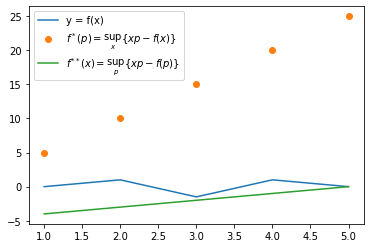

In [10]:
x = [1, 2, 3, 4, 5]
y = [0, 1, -1.5, 1, 0]

plt.plot(x, y, label=r'y = f(x)')
    
p = x
t, _ = legendre_fenchel(x, y, p)
plt.plot(p, t, 'o', label=r'$f^*(p) = \sup_{x}\{xp - f(x)\}$')

# f** gives the convex hull
yss, _ = legendre_fenchel(p, t, x)
plt.plot(x, yss, label=r'$f^{**}(x) = \sup_{p}\{xp - f(p)\}$')
plt.legend()
plt.show()

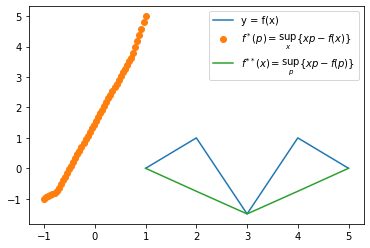

In [5]:
x = [1, 2, 3, 4, 5]
y = [0, 1, -1.5, 1, 0]

plt.plot(x, y, label=r'y = f(x)')
    
p = np.linspace(-1,1,50)
t, _ = legendre_fenchel(x, y, p)
plt.plot(p, t, 'o', label=r'$f^*(p) = \sup_{x}\{xp - f(x)\}$')

# f** gives the convex hull
yss, _ = legendre_fenchel(p, t, x)
plt.plot(x, yss, label=r'$f^{**}(x) = \sup_{p}\{xp - f(p)\}$')
plt.legend()
plt.show()

### Example. 2: Legendre-Fenchel is an identity for $f(x) = 0.5 x^2$

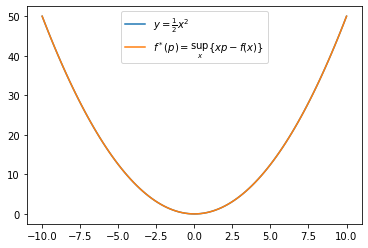

In [6]:
x = np.linspace(-10, 10, 101)          #[-10,10]を100等分(-10,…,10), numpy.linspace(最初の値,最後の値,要素数)  
y = 0.5*x**2

p = x
t, _ = legendre_fenchel(x, y, p)      #legendre_fenchelの関数の帰りから、tだけをとってくる
#print(t, _)
#print(np.abs(t - y))
assert np.max(np.abs(t - y)) == 0.        #assert 条件式, 条件式がFalseの場合に出力するメッセージ　（条件式がTrueではない時に、例外を投げる）
plt.plot(x, y, label=r'$y = \frac{1}{2}x^2$')
plt.plot(p, t, label=r'$f^*(p) = \sup_{x}\{xp - f(x)\}$')
plt.legend()
plt.show()

### Example. 3:  $f(x) = (x - 1)^2 (x + 1)^2$ 

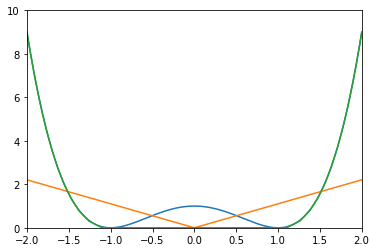

In [7]:
x = np.linspace(-2, 2, 1001)
y = (x - 1)**2 * (x + 1)**2

plt.plot(x, y, label=r'y = (x - 1)**2 * (x + 1)**2')
p = np.linspace(-1000, 1000, 1001)
t, _ = legendre_fenchel(x, y, p)
plt.plot(p, t, label=r'$f^*(p) = \sup_{x}\{xp - f(x)\}$')

# f** gives the convex hull
yss, _ = legendre_fenchel(p, t, x)
plt.plot(x, yss, label=r'$f^{**}(p) = \sup_{x}\{xp - f(x)\}$')
plt.xlim(-2,2)
plt.ylim(0,10)
plt.legend()
plt.show()